# Divergence‑Type Diffusion in (1+1)D with the Kurganov–Tadmor scheme

Solves the flux‑conservative system

$\partial_t n + \partial_x q = 0,\qquad
\partial_t(\lambda q) + \partial_x\alpha + \frac{1}{\sigma T}q = 0$,

where $(n(\alpha)$ is the equilibrium charge density and $\lambda,\sigma T$ are constant constitutive parameters.

L = 50.0, Nx = 1000, dx = 0.1000, t_end = 20.0
Simulation finished after 201 snapshots.


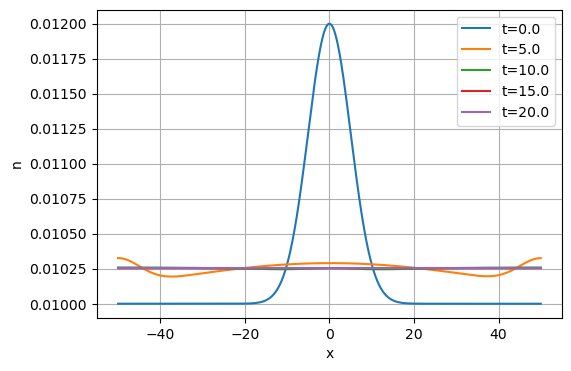

Saved to ./KT_DivType_snapshots/snapshots.npz


In [2]:
import numpy as np
from numba import jit
import matplotlib.pyplot as plt
import os

# ---------- physical parameters ----------
N_c, N_f = 3, 3
L         = 50.0
t_end     = 20.0
Nx        = 1000
dx        = 2.0 * L / Nx
xc        = np.linspace(-L + 0.5*dx, L - 0.5*dx, Nx)

sigmaT    = 1.0           # σ T
lam       = 1.0           # λ = τ_J/(σT)

# ---------- constitutive functions ----------
@jit(nopython=True, cache=False)
def T_func(t, x):
    return 0.3 * np.ones_like(x)

@jit(nopython=True, cache=False)
def alpha_from_n_func(n, T):
    a = T**3 * N_c * N_f
    b = np.sqrt(2187.0 * n**2 * T**12 * N_c**4 * N_f**4
                + 4.0 * np.pi**2 * a**6)
    c = 81.0 * n * a**2
    d = np.cbrt(np.sqrt(3.0) * b + c)
    term1 = (3.0/2.0)**(1.0/3.0) * np.pi**(2.0/3.0) * d / a
    term2 = 2.0**(1.0/3.0) * 3.0**(2.0/3.0) * np.pi**(4.0/3.0) * a / d
    return term1 - term2

@jit(nopython=True, cache=False)
def n_from_alpha_func(alpha, T):
    term1 = alpha / 27.0
    term2 = alpha**3 / (243.0 * np.pi**2)
    return N_c * N_f * T**3 * (term1 + term2)

# ---------- initial conditions ----------
@jit(nopython=True, cache=False)
def make_IC(xc):
    p, qq, r = 0.2, 7.0, 1.0
    n_init = (p * np.exp(-(qq * xc / L)**2) + r) * 1e-2

    d, f, g = 0.05, 10.0, 1.05
    q_init = (d * np.exp(-(f * xc / L)**2) + g) * 1e-2
    return n_init, q_init

# ---------- helper ----------
@jit(nopython=True, cache=False)
def roll1d(arr, shift):
    n = arr.size
    s = shift % n
    out = np.empty_like(arr)
    if s == 0:
        out[:] = arr
    else:
        out[:s] = arr[-s:]
        out[s:] = arr[:-s]
    return out

# ---------- numerical flux ----------
@jit(nopython=True, cache=False)
def numerical_flux(n, lam_q, T_arr):
    """
    n : charge density, shape (Nx,)
    lam_q : λ*q, shape (Nx,)
    T_arr : temperature, shape (Nx,)
    Returns face fluxes H at Nx interfaces (periodic), shape (2, Nx)
    """
    # minmod slopes
    dn  = (roll1d(n, -1) - n) / dx
    dnp = (n - roll1d(n, 1)) / dx
    sn = np.zeros_like(n)
    for i in range(Nx):
        if dn[i] * dnp[i] > 0.0:
            sn[i] = min(abs(dn[i]), abs(dnp[i])) * np.sign(dn[i])

    dlam = (roll1d(lam_q, -1) - lam_q) / dx
    dlamp = (lam_q - roll1d(lam_q, 1)) / dx
    slam = np.zeros_like(lam_q)
    for i in range(Nx):
        if dlam[i] * dlamp[i] > 0.0:
            slam[i] = min(abs(dlam[i]), abs(dlamp[i])) * np.sign(dlam[i])

    # face values (left and right of interface j+1/2)
    n_minus   = n + 0.5 * dx * sn
    lam_minus = lam_q + 0.5 * dx * slam
    n_plus    = roll1d(n, -1) - 0.5 * dx * roll1d(sn, -1)
    lam_plus  = roll1d(lam_q, -1) - 0.5 * dx * roll1d(slam, -1)

    # physical fluxes: F = (q, α)
    q_minus = lam_minus / lam
    q_plus  = lam_plus  / lam
    alpha_minus = alpha_from_n_func(n_minus, T_arr)
    alpha_plus  = alpha_from_n_func(n_plus, roll1d(T_arr, -1))

    # wave speeds: eigenvalues of Jacobian ± sqrt( dα/dn / λ )
    dn_dalpha_minus = (n_from_alpha_func(alpha_minus + 1e-8, T_arr)
                       - n_from_alpha_func(alpha_minus, T_arr)) / 1e-8
    dn_dalpha_plus  = (n_from_alpha_func(alpha_plus + 1e-8, roll1d(T_arr, -1))
                       - n_from_alpha_func(alpha_plus, roll1d(T_arr, -1))) / 1e-8
    dalpha_dn_minus = np.where(np.abs(dn_dalpha_minus) > 1e-12,
                               1.0 / dn_dalpha_minus, 1e12)
    dalpha_dn_plus  = np.where(np.abs(dn_dalpha_plus) > 1e-12,
                               1.0 / dn_dalpha_plus, 1e12)
    a_max = np.maximum(np.sqrt(np.abs(dalpha_dn_minus) / lam),
                       np.sqrt(np.abs(dalpha_dn_plus)  / lam))

    # Kurganov–Tadmor flux
    H = np.zeros((2, Nx))
    H[0] = 0.5 * (q_minus + q_plus) - 0.5 * a_max * (n_plus - n_minus)
    H[1] = 0.5 * (alpha_minus + alpha_plus) - 0.5 * a_max * (lam_plus - lam_minus)
    return H

# ---------- time stepping (RK2) ----------
@jit(nopython=True, cache=False)
def rhs(n, lam_q, T_arr):
    """
    d/dt (n, lam_q) = -div(F) + source
    """
    H = numerical_flux(n, lam_q, T_arr)   # shape (2, Nx)
    dU = np.zeros((2, Nx))
    # divergence using periodic differences
    dU[0] = -(H[0] - roll1d(H[0], 1)) / dx
    dU[1] = -(H[1] - roll1d(H[1], 1)) / dx - lam_q / (lam * sigmaT)
    return dU

@jit(nopython=True, cache=False)
def step_RK2(n, lam_q, T_arr, dt):
    k1 = rhs(n, lam_q, T_arr)
    n1   = n     + dt * k1[0]
    q1   = lam_q + dt * k1[1]
    k2 = rhs(n1, q1, T_arr)
    n_out   = n     + 0.5 * dt * (k1[0] + k2[0])
    lam_out = lam_q + 0.5 * dt * (k1[1] + k2[1])
    return n_out, lam_out

# ---------- main simulation ----------
print(f"L = {L}, Nx = {Nx}, dx = {dx:.4f}, t_end = {t_end}")

n, q0 = make_IC(xc)
lam_q = lam * q0

save_times = np.linspace(0, t_end, 201)
save_idx   = 0
n_store    = np.zeros((len(save_times), Nx))
q_store    = np.zeros((len(save_times), Nx))
alpha_store= np.zeros((len(save_times), Nx))

n_store[0]   = n
q_store[0]   = q0
alpha_store[0] = alpha_from_n_func(n, T_func(0.0, xc))

t = 0.0
while t < t_end:
    T_arr = T_func(t, xc)
    # compute characteristic speed
    alpha_cur = alpha_from_n_func(n, T_arr)
    dn_dalpha = (n_from_alpha_func(alpha_cur + 1e-8, T_arr)
                 - n_from_alpha_func(alpha_cur, T_arr)) / 1e-8
    dalpha_dn = np.where(np.abs(dn_dalpha) > 1e-12, 1.0 / dn_dalpha, 1e12)
    a_max = np.sqrt(np.abs(dalpha_dn) / lam)
    dt_cfl = np.min(0.4 * dx / a_max)          # scalar, global minimum
    dt = min(dt_cfl, t_end - t)

    n, lam_q = step_RK2(n, lam_q, T_arr, dt)
    t += dt

    # save snapshots
    if save_idx+1 < len(save_times) and t >= save_times[save_idx+1]:
        save_idx += 1
        n_store[save_idx]   = n
        q_store[save_idx]   = lam_q / lam
        alpha_store[save_idx] = alpha_from_n_func(n, T_arr)

print(f"Simulation finished after {save_idx+1} snapshots.")

# ---------- quick plot ----------
plt.figure(figsize=(6,4))
for i in [0, 50, 100, 150, 200]:
    plt.plot(xc, n_store[i], label=f't={save_times[i]:.1f}')
plt.xlabel('x'); plt.ylabel('n'); plt.legend(); plt.grid(True)
plt.show()

# ---------- save results ----------
run_dir = "./KT_DivType"
os.makedirs(run_dir, exist_ok=True)
np.savez(os.path.join(run_dir, "snapshots.npz"),
         t=save_times, x=xc,
         n=n_store, q=q_store, alpha=alpha_store)
print(f"Saved to {run_dir}/snapshots.npz")